### Week 8 — Sentiment Analysis
1. Task:
   - Use a reviews dataset.

2. Steps:
   - Preprocess text
   - Train sentiment model
   - Predict sentiment for new reviews

3. Example predictions:

    - "Product is amazing" → Positive

    - "Worst experience" → Negative

### importing Libraries

In [1]:
import re
import string

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_colwidth", 100)
print("Libraries imported successfully.")

Libraries imported successfully.


### Load Dataset

In [2]:
df = pd.read_csv('Customer_Sentiment.csv')
print('Shape:',df.shape)
df.head()

Shape: (9998, 13)


,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,other,26-35,south,electronics,online,myntra,5,It is not an out of the world product but for the price point it is what it is said to be . It d...,positive,68,no,no
1,2,male,46-60,west,electronics,online,zepto,3,I like it. Bought it as a birthday gift for a three year old and they love it,neutral,70,no,no
2,3,male,60+,west,electronics,online,bigbasket,4,I purchased this tablet for my grandson who is 4 years old. He loves it!,positive,51,no,no
3,4,other,18-25,central,electronics,online,croma,4,Perfect for my elderly mom to play games and use for reading,positive,22,no,yes
4,5,male,36-45,north,electronics,online,shopclues,5,Got this as a gift for my best friend. It arrived very fast; packed nicely; gift wrapped. Qualit...,positive,68,no,no


In [3]:
# we only need the review text and sentiment label.
data = df[['customer_id','review_text','sentiment']].dropna().copy()
print(data['sentiment'].value_counts())
data.head()

sentiment
positive    7689
neutral     1499
negative     810
Name: count, dtype: int64


,customer_id,review_text,sentiment
0,1,It is not an out of the world product but for the price point it is what it is said to be . It d...,positive
1,2,I like it. Bought it as a birthday gift for a three year old and they love it,neutral
2,3,I purchased this tablet for my grandson who is 4 years old. He loves it!,positive
3,4,Perfect for my elderly mom to play games and use for reading,positive
4,5,Got this as a gift for my best friend. It arrived very fast; packed nicely; gift wrapped. Qualit...,positive


### Visualization for customer review 

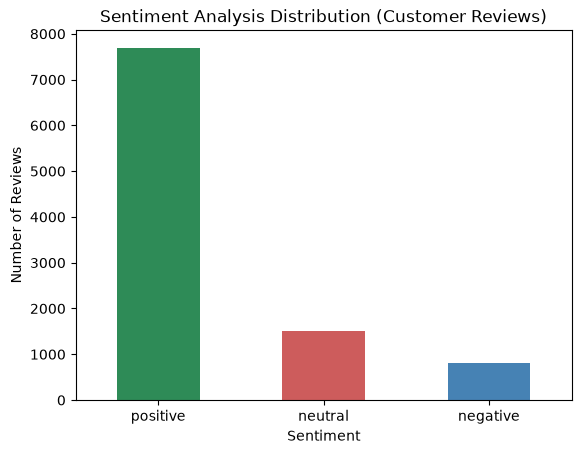

In [4]:
data['sentiment'].value_counts().plot(kind='bar',color=['seagreen','indianred','steelblue'])
plt.title('Sentiment Analysis Distribution (Customer Reviews)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

### Text Preprocessing

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def text_preprocess(review):
    review = str(review).lower()
    review = re.sub(r'[^a-zA-Z]',' ',review)
    token = review.split()
    token = [
        lemmatizer.lemmatize(t,pos='v')
        for t in token if t not in stop_words
    ]
    return ' '.join(token)

data['cleaned_review'] = data['review_text'].apply(text_preprocess)
data[['review_text','cleaned_review','sentiment']].head(10)
    

,review_text,cleaned_review,sentiment
0,It is not an out of the world product but for the price point it is what it is said to be . It d...,world product price point say advertise nothing lessa little slower compare samsung tabs ipads l...,positive
1,I like it. Bought it as a birthday gift for a three year old and they love it,like buy birthday gift three year old love,neutral
2,I purchased this tablet for my grandson who is 4 years old. He loves it!,purchase tablet grandson years old love,positive
3,Perfect for my elderly mom to play games and use for reading,perfect elderly mom play game use read,positive
4,Got this as a gift for my best friend. It arrived very fast; packed nicely; gift wrapped. Qualit...,get gift best friend arrive fast pack nicely gift wrap quality great,positive
5,"I bought this on Black Friday, simply because it was dirt cheap. It works ok but kinda slow.",buy black friday simply dirt cheap work ok kinda slow,negative
6,Alexa has a hard time answering. You need to download information online in order to build her d...,alexa hard time answer need download information online order build data base,negative
7,Crazy that you have to buy these separate for some kindle products that should come with one,crazy buy separate kindle products come one,negative
8,"I, as well as other Kindle lovers, have noticed that although we have taken great care with the ...",well kindle lovers notice although take great care cover warp bubble durable within months start...,negative
9,Easy to setup and use. Even without peripherals the syste interaction was beneficial,easy setup use even without peripherals syste interaction beneficial,positive


### Train/Test Split

In [6]:
X = data['cleaned_review']
y =data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42, stratify=y)

# print('Train Size:',X_train.shape[0])
# print('Test Size:',X_test.shape[0])
print(y.value_counts())

sentiment
positive    7689
neutral     1499
negative     810
Name: count, dtype: int64


In [7]:
print(data['cleaned_review'].duplicated().sum())
print(data['cleaned_review'].nunique())

10
9988


### Feature Extraction (TF-IDF)
- Convert cleaned text into numerical features using TF-IDF (Term Frequency–Inverse Document Frequency).

In [8]:
#im using the bigram because some review might be "not good","product good" so its easy for model to predict.
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)


X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF matrix:',X_train_tfidf.shape)

TF-IDF matrix: (6998, 65531)


### Train Sentiment Analysis Model

In [9]:
from sklearn.naive_bayes import MultinomialNB
# model = LogisticRegression(max_iter=1000, class_weight='balanced')

model = MultinomialNB()
model.fit(X_train_tfidf,y_train)

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test,y_pred)
print(f'Test Accuracy:{accuracy:.2f}')
print(classification_report(y_test,y_pred))

Test Accuracy:0.77
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       243
     neutral       0.00      0.00      0.00       450
    positive       0.77      1.00      0.87      2307

    accuracy                           0.77      3000
   macro avg       0.26      0.33      0.29      3000
weighted avg       0.59      0.77      0.67      3000



c:\Users\DinakaranThiruvarasu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DinakaranThiruvarasu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DinakaranThiruvarasu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

## 7. Predict Sentiment for New, Unseen Reviews

Now we use the trained pipeline (preprocess → TF-IDF → model) to predict sentiment for brand-new review text that was never in the training data.

In [10]:
def predict_sentiment(review_text):
    cleaned = text_preprocess(review_text)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    confidence = dict(zip(model.classes_, proba))
    return pred, confidence

new_reviews = [
    'Product is amazing',
    'Worst experience',
    'The delivery was super fast and the packaging was great',
    'I am extremely unhappy with the quality of this item',
    'It is okay, nothing special about it',
    'Absolutely love this, will buy again!',
    'Terrible customer service and broken item on arrival'
]

for review in new_reviews:
    pred, conf = predict_sentiment(review)

    print("=" * 60)
    print(f"Review    : {review}")
    print(f"Sentiment : {pred.upper()}")
    print(f"Confidence: {max(conf.values()):.2%}")

Review    : Product is amazing
Sentiment : POSITIVE
Confidence: 96.65%
Review    : Worst experience
Sentiment : POSITIVE
Confidence: 73.00%
Review    : The delivery was super fast and the packaging was great
Sentiment : POSITIVE
Confidence: 96.99%
Review    : I am extremely unhappy with the quality of this item
Sentiment : POSITIVE
Confidence: 91.86%
Review    : It is okay, nothing special about it
Sentiment : POSITIVE
Confidence: 59.09%
Review    : Absolutely love this, will buy again!
Sentiment : POSITIVE
Confidence: 99.31%
Review    : Terrible customer service and broken item on arrival
Sentiment : POSITIVE
Confidence: 91.24%
